In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


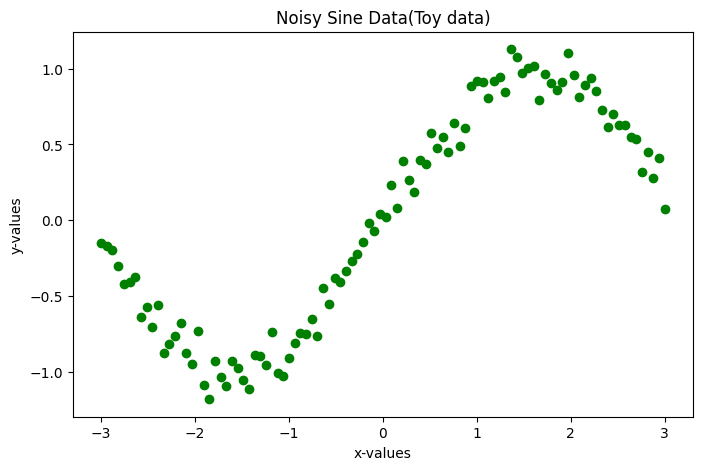

Initial weight: 0.017359638031652493
Initial bias: 0.001979107834626478


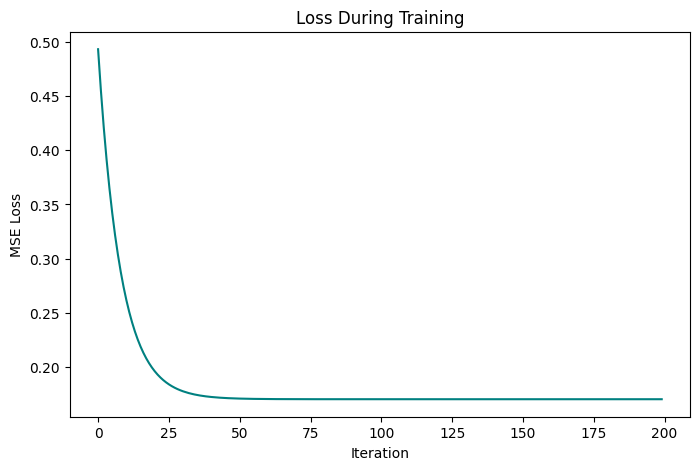

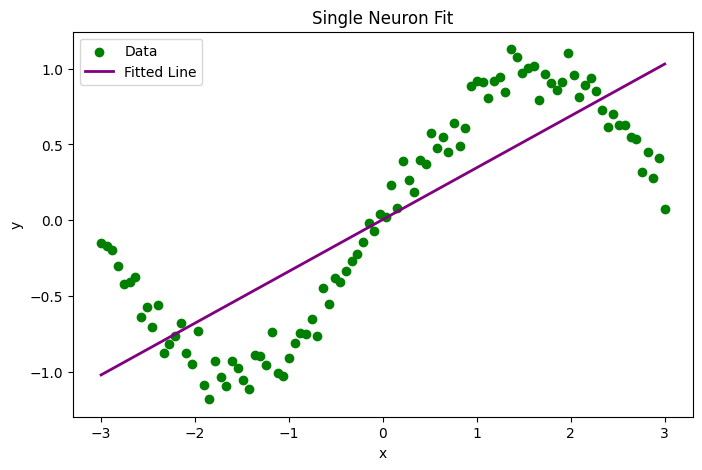

In [11]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x)

# add some noise
noise = np.random.normal(0, 0.1, size=x.shape)
y = y + noise

#   Plot it.
plt.figure(figsize=(8,5))
plt.scatter(x, y, color="green")
plt.title("Noisy Sine Data(Toy data)")
plt.xlabel("x-values")
plt.ylabel("y-values")
plt.show()

# TODO: Initialise w and b to small random values.
# multiply by 0.01 to get small values
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

print("Initial weight:", w)
print("Initial bias:", b)

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
learning_rate = 0.01
epochs = 200

loss_history = []

for epoch in range(epochs):
  # Forward pass
  y_hat = w * x + b

  # Compute loss
  loss = np.mean((y_hat - y) ** 2)

  # Compute gradients
  dw = np.mean(2 * (y_hat - y) * x)
  db = np.mean(2 * (y_hat - y))

  # Update parameters
  w -= learning_rate * dw
  b -= learning_rate * db

  # Record the loss at every step
  loss_history.append(loss)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# (a) the loss curve over the 200 steps, and
plt.figure(figsize=(8,5))
plt.plot(loss_history, color="teal")
plt.title("Loss During Training")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.show()

# (b) the data with the fitted line on top.
plt.figure(figsize=(8,5))
plt.scatter(x, y, label="Data", color="green")
plt.plot(x, w * x + b, color="purple", linewidth=2, label="Fitted Line")
plt.title("Single Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Student Reasoning — The single neuron

**1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?**

![WhatsApp Image 2026-07-28 at 3.26.17 PM.jpeg](<attachment:WhatsApp Image 2026-07-28 at 3.26.17 PM.jpeg>)

This matches the implementation in the code:

```python
dw = np.mean(2 * (y_hat - y) * x)
```

because `np.mean(...)` computes the average, which is equivalent to

$$
\frac{1}{n}\sum.
$$

---
**2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?**

The model is **underfitting**, not overfitting.

A single neuron can only learn a **linear relationship**, since its prediction is

$$
\hat{y}=wx+b,
$$

which represents a straight line. However, the target function

$$
y=\sin(x)
$$

is **non-linear** and continuously curves up and down. No matter how long the model is trained, adjusting only the weight \(w\) and bias \(b\) can only change the slope and position of the line. It cannot produce the curved shape of a sine wave.

As a result, the loss decreases at first because the model finds the best possible straight line, but it eventually stops improving because the model has reached the limit of its capacity. This is an example of **underfitting**, where the model is too simple to capture the underlying pattern in the data.
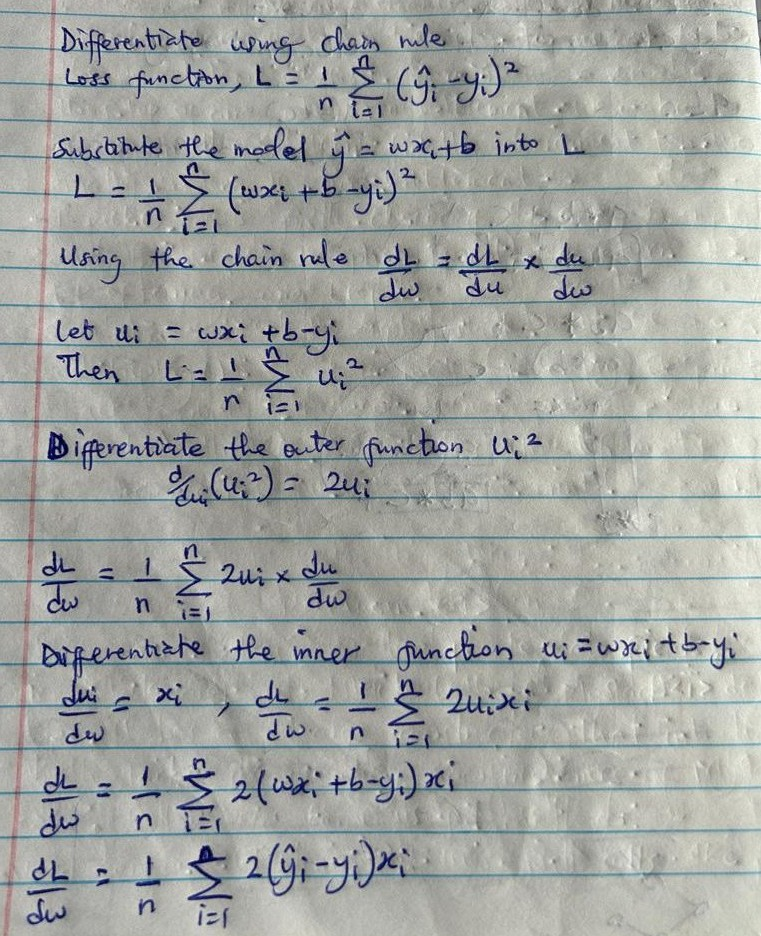